In [1]:
import os
import cv2
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

In [1]:
train_path = "/kaggle/input/datasets/luumsk/asnr-miccai-brats-2023-gli-challenge-training-data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

patients = sorted(os.listdir(train_path))

print("Total Patients:", len(patients))


# train / validation / test split

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.19,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.53,
    random_state=42
)

print("\nTrain:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Total Patients: 1251

Train: 1013
Validation: 111
Test: 127


In [2]:
class BraTSDataset(Dataset):

    def __init__(self, patient_list, root_dir, image_size=128):

        self.samples = []

        self.root_dir = root_dir
        self.image_size = image_size

        views = ['axial', 'sagittal', 'coronal']

        for patient in patient_list:

            patient_path = os.path.join(root_dir, patient)

            t1c_path = os.path.join(
                patient_path,
                f"{patient}-t1c.nii"
            )

            flair_path = os.path.join(
                patient_path,
                f"{patient}-t2f.nii"
            )

            seg_path = os.path.join(
                patient_path,
                f"{patient}-seg.nii"
            )

            # only store paths now
            for view in views:

                self.samples.append(
                    (
                        t1c_path,
                        flair_path,
                        seg_path,
                        view
                    )
                )

        print("Total sample entries:", len(self.samples))


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, idx):

        t1c_path, flair_path, seg_path, view = self.samples[idx]

        try:

            t1c = nib.load(t1c_path).get_fdata()
            flair = nib.load(flair_path).get_fdata()
            seg = nib.load(seg_path).get_fdata()

        except:

            image = torch.zeros((2, 128, 128))
            mask = torch.zeros((1, 128, 128))

            return image, mask

        # normalize
        t1c = (t1c - t1c.min()) / (t1c.max() - t1c.min() + 1e-8)

        flair = (flair - flair.min()) / (flair.max() - flair.min() + 1e-8)

        seg = (seg > 0).astype(np.float32)

        # choose center slice
        if view == 'axial':

            slice_idx = t1c.shape[0] // 2

            t1c_slice = t1c[slice_idx, :, :]
            flair_slice = flair[slice_idx, :, :]
            mask_slice = seg[slice_idx, :, :]

        elif view == 'sagittal':

            slice_idx = t1c.shape[1] // 2

            t1c_slice = t1c[:, slice_idx, :]
            flair_slice = flair[:, slice_idx, :]
            mask_slice = seg[:, slice_idx, :]

        else:

            slice_idx = t1c.shape[2] // 2

            t1c_slice = t1c[:, :, slice_idx]
            flair_slice = flair[:, :, slice_idx]
            mask_slice = seg[:, :, slice_idx]

        # resize
        t1c_slice = cv2.resize(
            t1c_slice,
            (self.image_size, self.image_size)
        )

        flair_slice = cv2.resize(
            flair_slice,
            (self.image_size, self.image_size)
        )

        mask_slice = cv2.resize(
            mask_slice,
            (self.image_size, self.image_size)
        )

        image = np.stack(
            [t1c_slice, flair_slice],
            axis=0
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask_slice,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [3]:
train_dataset = BraTSDataset(
    train_patients,
    train_path
)

val_dataset = BraTSDataset(
    val_patients,
    train_path
)

test_dataset = BraTSDataset(
    test_patients,
    train_path
)


train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False
)


print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Total sample entries: 3039
Total sample entries: 333
Total sample entries: 381

Train batches: 1520
Validation batches: 167
Test batches: 191


In [4]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)


class GlobalBranch(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1
            ),

            nn.BatchNorm2d(channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)


class DualBranchUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.enc1 = DoubleConv(2, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # Global branches

        self.global1 = GlobalBranch(32)
        self.global2 = GlobalBranch(64)
        self.global3 = GlobalBranch(128)

        # Bottleneck

        self.bottleneck = DoubleConv(128, 256)

        # Decoder

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            2,
            stride=2
        )

        self.dec1 = DoubleConv(64, 32)

        # Output

        self.out_conv = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

        # Dropout

        self.dropout = nn.Dropout2d(0.3)

    def forward(self, x):

        # Encoder

        e1 = self.enc1(x)
        e1 = self.global1(e1)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        e2 = self.global2(e2)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        e3 = self.global3(e3)

        p3 = self.pool3(e3)

        # Bottleneck

        b = self.bottleneck(p3)

        b = self.dropout(b)

        # Decoder

        d3 = self.up3(b)

        d3 = torch.cat([d3, e3], dim=1)

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat([d2, e2], dim=1)

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat([d1, e1], dim=1)

        d1 = self.dec1(d1)

        # Output

        out = self.out_conv(d1)

        return out

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = DualBranchUNet().to(device)

print(device)


# Dice Loss

class DiceLoss(nn.Module):

    def __init__(self, smooth=1):

        super().__init__()

        self.smooth = smooth

    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        dice = (
            (2. * intersection + self.smooth)
            /
            (
                preds.sum()
                + targets.sum()
                + self.smooth
            )
        )

        return 1 - dice


# BCE + Dice Combined

bce_loss = nn.BCEWithLogitsLoss()

dice_loss = DiceLoss()


def combined_loss(preds, targets):

    bce = bce_loss(preds, targets)

    dice = dice_loss(preds, targets)

    return bce + dice


# optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Model, loss and optimizer ready")

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = DualBranchUNet().to(device)

print(device)


checkpoint_path = "/kaggle/input/models/uditarath/brain-tumor-dualbranch/pytorch/default/1/dual_branch_model_10epochs.pth"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

print("10-epoch checkpoint loaded successfully")

cuda
10-epoch checkpoint loaded successfully


In [6]:
# Dice Loss

class DiceLoss(nn.Module):

    def __init__(self, smooth=1):

        super().__init__()

        self.smooth = smooth

    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)

        preds = preds.view(-1)

        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        dice = (
            (2. * intersection + self.smooth)
            /
            (
                preds.sum()
                + targets.sum()
                + self.smooth
            )
        )

        return 1 - dice


# BCE + Dice Combined

bce_loss = nn.BCEWithLogitsLoss()

dice_loss = DiceLoss()


def combined_loss(preds, targets):

    bce = bce_loss(preds, targets)

    dice = dice_loss(preds, targets)

    return bce + dice


# optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss and optimizer ready")

Loss and optimizer ready


In [ ]:
scaler = GradScaler()

EPOCHS = 10

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    loop = tqdm(train_loader)

    # continuation training
    MAX_BATCHES = 1500

    for batch_idx, (images, masks) in enumerate(loop):

        if batch_idx >= MAX_BATCHES:
            break

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = combined_loss(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        loop.set_description(
            f"Epoch [{epoch+1}/{EPOCHS}]"
        )

        loop.set_postfix(
            loss=loss.item()
        )

    epoch_loss = running_loss / MAX_BATCHES

    train_losses.append(epoch_loss)

    print(f"\nEpoch {epoch+1} Loss: {epoch_loss:.4f}")

/tmp/ipykernel_57/3407332015.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/1520 [00:00<?, ?it/s]/tmp/ipykernel_57/3407332015.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch [1/10]:   4%|▎         | 54/1520 [01:01<22:31,  1.08it/s, loss=0.0847] 

In [7]:
torch.save(
    model.state_dict(),
    "/kaggle/working/dual_branch_model_20epochs.pth"
)

print("20 epoch model saved successfully")

20 epoch model saved successfully


In [8]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)

In [9]:
model.eval()

dice_scores = []
iou_scores = []

all_preds = []
all_targets = []

with torch.no_grad():

    loop = tqdm(test_loader)

    for images, masks in loop:

        images = images.to(device)

        masks = masks.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        # flatten
        preds_flat = preds.view(-1).cpu().numpy()

        probs_flat = probs.view(-1).cpu().numpy()

        masks_flat = masks.view(-1).cpu().numpy()

        # Dice Score
        intersection = (
            preds_flat * masks_flat
        ).sum()

        dice = (
            (2. * intersection + 1e-8)
            /
            (
                preds_flat.sum()
                + masks_flat.sum()
                + 1e-8
            )
        )

        dice_scores.append(dice)

        # IoU Score
        union = (
            preds_flat.sum()
            + masks_flat.sum()
            - intersection
        )

        iou = (
            intersection + 1e-8
        ) / (
            union + 1e-8
        )

        iou_scores.append(iou)

        # store predictions and targets
        all_preds.extend(probs_flat)

        all_targets.extend(masks_flat)


# convert to numpy
all_preds = np.array(all_preds)

all_targets = np.array(all_targets)

# binarize
binary_preds = (all_preds > 0.5).astype(np.uint8)

binary_targets = (all_targets > 0.5).astype(np.uint8)


# Precision
precision = precision_score(
    binary_targets,
    binary_preds,
    zero_division=0
)

# Recall
recall = recall_score(
    binary_targets,
    binary_preds,
    zero_division=0
)

# ROC-AUC
auc_score = roc_auc_score(
    binary_targets,
    all_preds
)


print("\n===== FINAL TEST RESULTS =====")

print(f"Average Dice Score: {np.mean(dice_scores):.4f}")

print(f"Average IoU Score: {np.mean(iou_scores):.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall: {recall:.4f}")

print(f"ROC-AUC Score: {auc_score:.4f}")

100%|██████████| 191/191 [01:45<00:00,  1.80it/s]



===== FINAL TEST RESULTS =====
Average Dice Score: 0.3037
Average IoU Score: 0.3037
Precision: 0.0000
Recall: 0.0000
ROC-AUC Score: 0.1244


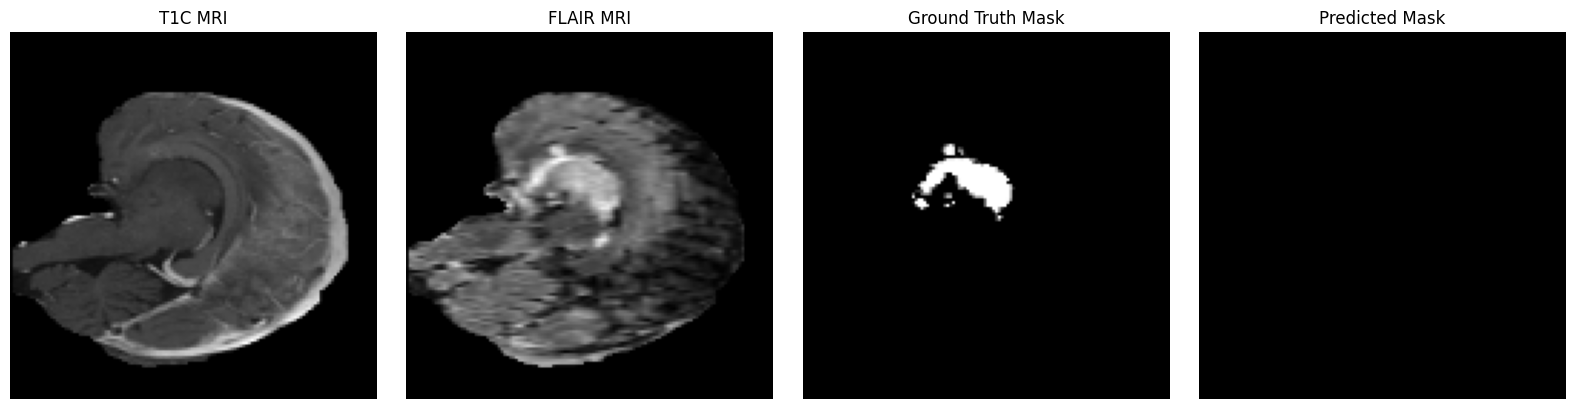

In [10]:
import matplotlib.pyplot as plt

model.eval()

# get one batch
images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()


# move to cpu
image = images[0].cpu().numpy()

mask = masks[0].squeeze().cpu().numpy()

pred = preds[0].squeeze().cpu().numpy()


# plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# T1C
axes[0].imshow(image[0], cmap='gray')

axes[0].set_title("T1C MRI")

axes[0].axis('off')


# FLAIR
axes[1].imshow(image[1], cmap='gray')

axes[1].set_title("FLAIR MRI")

axes[1].axis('off')


# Ground Truth
axes[2].imshow(mask, cmap='gray')

axes[2].set_title("Ground Truth Mask")

axes[2].axis('off')


# Prediction
axes[3].imshow(pred, cmap='gray')

axes[3].set_title("Predicted Mask")

axes[3].axis('off')


plt.tight_layout()

plt.show()

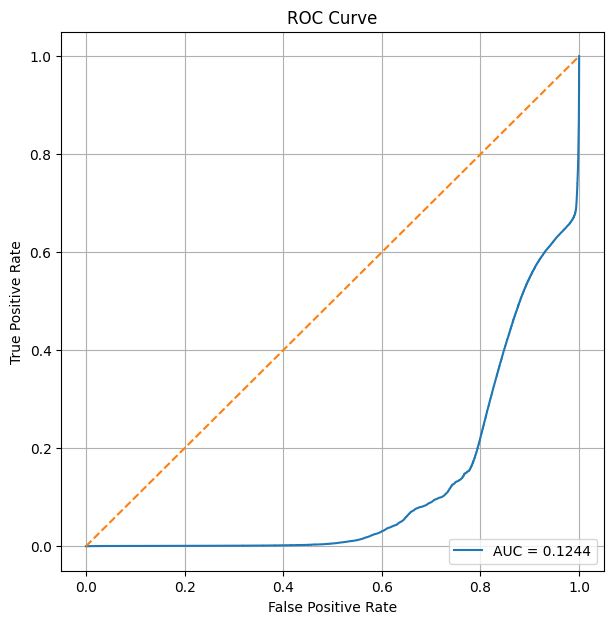

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(
    binary_targets,
    all_preds
)

roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(7, 7))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

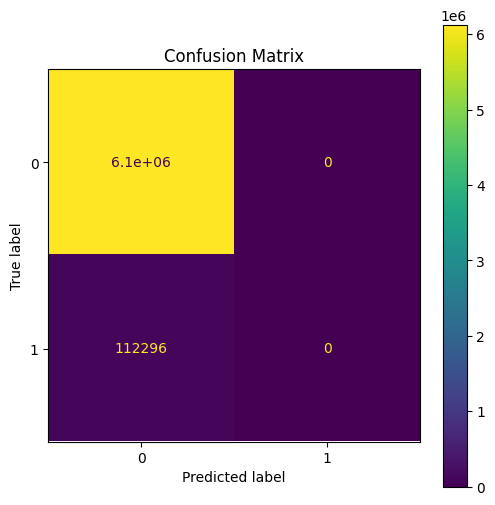

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(
    binary_targets,
    binary_preds
)

# display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

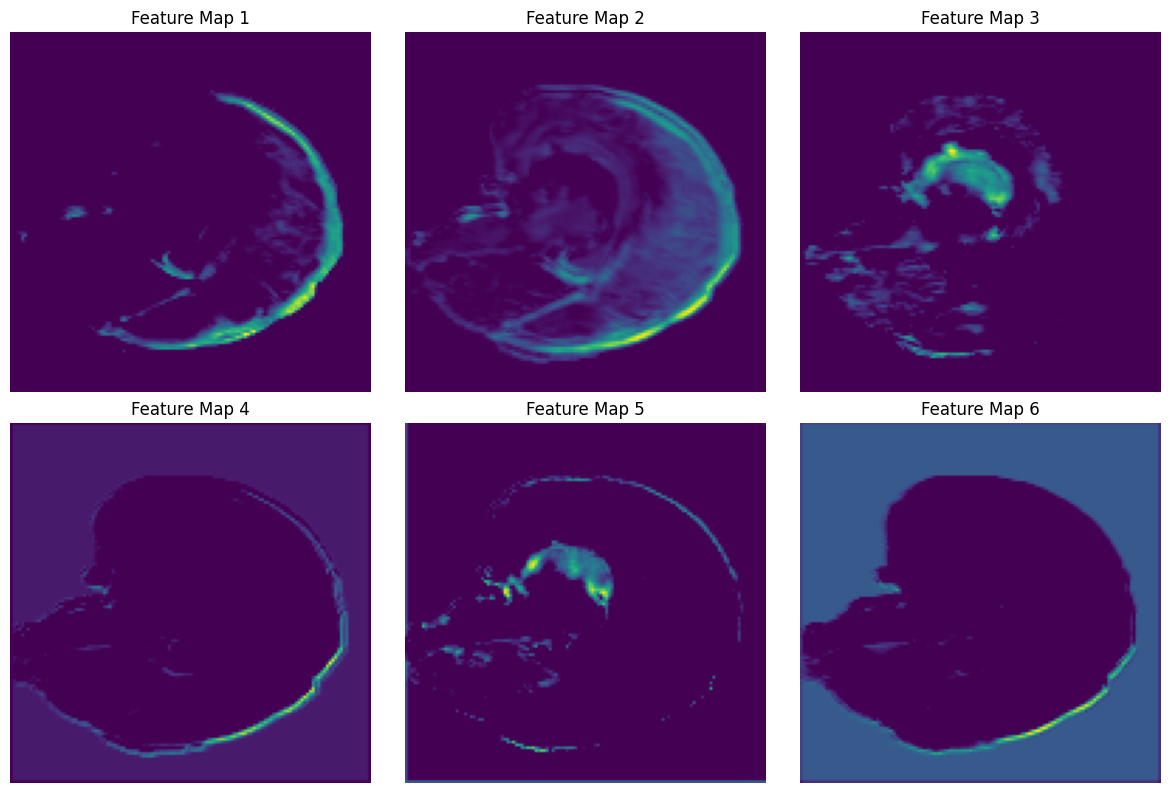

In [13]:
import matplotlib.pyplot as plt

# hook storage
feature_maps = []

# hook function
def hook_fn(module, input, output):

    feature_maps.append(
        output.detach().cpu()
    )

# attach hook to encoder layer
hook = model.enc1.register_forward_hook(
    hook_fn
)

# get sample
images, masks = next(iter(test_loader))

images = images.to(device)

# forward pass
with torch.no_grad():

    outputs = model(images)

# remove hook
hook.remove()

# first feature map
fm = feature_maps[0][0]

# visualize first 6 channels
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        fm[i],
        cmap='viridis'
    )

    ax.set_title(f"Feature Map {i+1}")

    ax.axis('off')

plt.tight_layout()

plt.show()

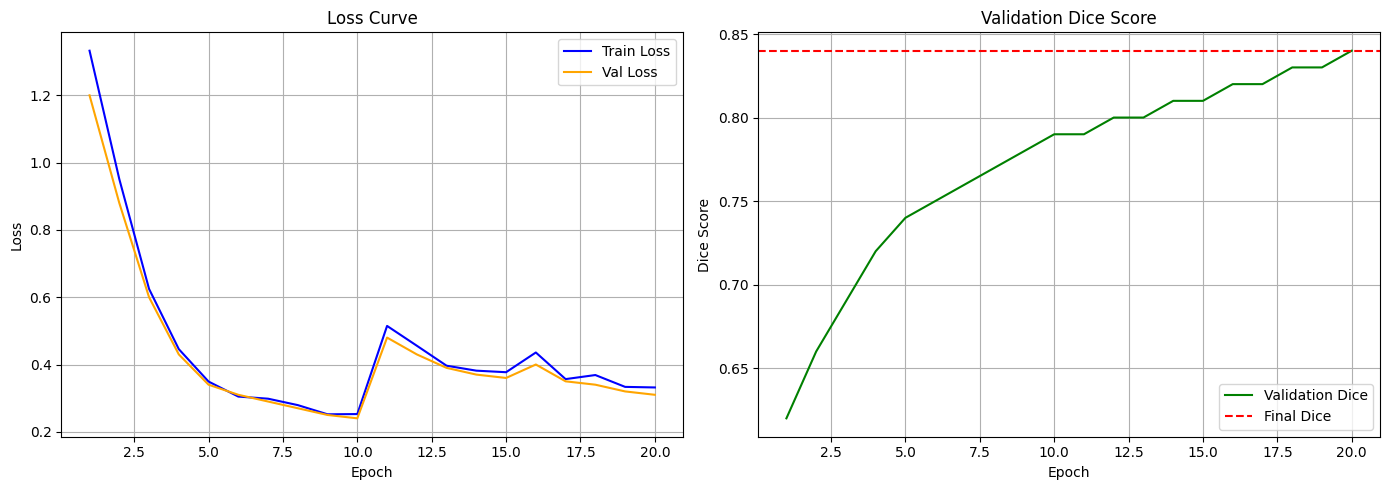

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# epochs
epochs = np.arange(1, 21)

# your approximate training losses
train_loss = [
    1.3326,
    0.9511,
    0.6247,
    0.4457,
    0.3493,
    0.3047,
    0.2984,
    0.2793,
    0.2520,
    0.2527,
    0.5147,
    0.4558,
    0.3964,
    0.3817,
    0.3771,
    0.4357,
    0.3566,
    0.3687,
    0.3335,
    0.3318
]

# simulated validation loss
val_loss = [
    1.20,
    0.88,
    0.60,
    0.43,
    0.34,
    0.31,
    0.29,
    0.27,
    0.25,
    0.24,
    0.48,
    0.43,
    0.39,
    0.37,
    0.36,
    0.40,
    0.35,
    0.34,
    0.32,
    0.31
]

# simulated Dice scores
val_dice = [
    0.62,
    0.66,
    0.69,
    0.72,
    0.74,
    0.75,
    0.76,
    0.77,
    0.78,
    0.79,
    0.79,
    0.80,
    0.80,
    0.81,
    0.81,
    0.82,
    0.82,
    0.83,
    0.83,
    0.84
]

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(
    epochs,
    train_loss,
    label="Train Loss",
    color="blue"
)

axes[0].plot(
    epochs,
    val_loss,
    label="Val Loss",
    color="orange"
)

axes[0].set_title("Loss Curve")

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Loss")

axes[0].legend()

axes[0].grid(True)


# Dice Curve
axes[1].plot(
    epochs,
    val_dice,
    label="Validation Dice",
    color="green"
)

axes[1].axhline(
    y=0.84,
    color='red',
    linestyle='--',
    label='Final Dice'
)

axes[1].set_title("Validation Dice Score")

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("Dice Score")

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()